# 01 — Stylistic Shift Analysis

**The question:** when GPT-4, Claude 3, Mistral 7B, and Gemini Pro rewrite a Zola paragraph, where does the style go?

This notebook measures *stylistic shift* — the cosine distance between a text's function-word fingerprint before and after LLM rewriting — across **80 French literary passages** (Zola + Maupassant).

| Section | What you'll see |
|---------|----------------|
| 1 | The same paragraph, four ways |
| 2 | Function-word vectors explained |
| 3 | Shifts across all 80 texts + bootstrap CI |
| 4 | Drift trajectories in PCA style-space |
| 5 | Per-word deviation heatmap |
| 6 | KDE ridgeline: distribution overlap |

> **No API key required** — all LLM outputs are pre-generated in `data/`.

In [1]:
import sys, re
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from matplotlib.transforms import blended_transform_factory
from scipy.stats import gaussian_kde
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
import seaborn as sns

ROOT = Path().resolve().parent
sys.path.insert(0, str(ROOT))

from src.stylometry import StyleAnalyzer, PALETTE
from src.stats import bootstrap_ci
from src.data import load_originals, load_llm_corpora, load_human

plt.style.use('dark_background')
THEME = dict(bg='#0D1117', surface='#161B22', grid='#21262D',
             text='#E6EDF3', muted='#8B949E', spine='#30363D')
plt.rcParams.update({'font.size': 10, 'axes.titlesize': 12, 'axes.labelsize': 10})

sa          = StyleAnalyzer()
originals   = load_originals()    # 80 texts
llm_corpora = load_llm_corpora()  # {label: [80 rewrites]}

print(f'Originals : {len(originals)} texts')
for name, texts in llm_corpora.items():
    print(f'  {name:<15} {len(texts)} rewrites')

Originals : 80 texts
  GPT-4           80 rewrites
  Claude 3        80 rewrites
  Mistral 7B      80 rewrites
  Gemini Pro      80 rewrites


## 1 — The same paragraph, four ways

Each model received: *"Réécris ce texte dans un style neutre et factuel, en conservant le sens."*

Notice the differences before any measurement:
- **GPT-4** — strips syntax to its functional minimum, `et` as dominant connector
- **Claude 3** — formal subordination, `tandis que`, participial constructions
- **Mistral 7B** — conservative paraphrase, tense inconsistency
- **Gemini Pro** — explicit causal connectors (`en raison de`, `afin de`), mood → description

Change `idx` to explore any of the 80 texts (0–79).

In [2]:
idx = 0  # Change to any value 0–79

sep = '─' * 72
print(sep)
print('ORIGINAL — Zola')
print(sep)
print(originals[idx])
print()
for name, texts in llm_corpora.items():
    shift = sa.shift(originals[idx], texts[idx])
    print(sep)
    print(f'{name.upper()}  (shift = {shift:.4f})')
    print(sep)
    print(texts[idx])
    print()

────────────────────────────────────────────────────────────────────────
ORIGINAL — Zola
────────────────────────────────────────────────────────────────────────
Dans la plaine rase, sous la nuit sans étoiles, d'une obscurité et d'une épaisseur d'encre, un homme suivait seul la grande route de Marchiennes à Montsou, dix kilomètres de pavé coupant tout droit, à travers les champs de betteraves. Il ne voyait même pas le sol noir devant lui, et il n'avait la sensation de l'immense horizon plat que par les souffles du vent de mars, des rafales larges comme sur une mer, glacées d'avoir balayé des lieues de marais et de terres nues.

────────────────────────────────────────────────────────────────────────
GPT-4  (shift = 0.0788)
────────────────────────────────────────────────────────────────────────
Dans la plaine, sous une nuit dépourvue d'étoiles et extrêmement sombre, un homme marchait seul sur la grande route reliant Marchiennes à Montsou. Ce chemin pavé s'étendait sur dix kilomètres en

## 2 — What stylometry measures

Each text is projected into a **41-dimensional vector** of L2-normalised function-word frequencies:

```
v(t) = [freq(le), freq(la), freq(et), ..., freq(notamment)]  — L2-normalised
```

The **stylistic shift** is the cosine distance between original and rewrite:

```python
shift(t, t') = 1 - dot(v(t), v(t')) / (norm(v(t)) * norm(v(t')))
```

- Shift = **0.0** → identical function-word distribution
- Shift = **0.23** (Gemini avg) → substantial displacement

In [3]:
orig   = originals[idx]
v_orig = sa.fit_transform([orig])[0]

print('Function-word vector of the original (first 12 of 41 dimensions):')
for word, val in zip(sa.function_words[:12], v_orig[:12]):
    bar = '█' * int(val * 250)
    print(f'  {word:<14} {val:.4f}  {bar}')
print(f'  ... ({len(sa.function_words)} total)')
print()
print('Shift per model on this single text:')
for name, texts in llm_corpora.items():
    shift = sa.shift(orig, texts[idx])
    bar   = '█' * int(shift * 100)
    print(f'  {name:<15} {shift:.4f}  {bar}')

Function-word vector of the original (first 12 of 41 dimensions):
  le             0.0967  ████████████████████████
  la             0.3867  ████████████████████████████████████████████████████████████████████████████████████████████████
  les            0.1933  ████████████████████████████████████████████████
  un             0.0967  ████████████████████████
  une            0.2900  ████████████████████████████████████████████████████████████████████████
  des            0.1933  ████████████████████████████████████████████████
  de             0.6767  █████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
  du             0.0967  ████████████████████████
  et             0.2900  ████████████████████████████████████████████████████████████████████████
  ou             0.0000  
  mais           0.0000  
  donc           0.0000  
  ... (41 total)

Shift per model on this sin

## 3 — Shifts across all 80 texts

Computing the shift for every original → rewrite pair (80 per model), then running **5,000 bootstrap resamples** for the confidence intervals.

A non-overlapping CI between two models = statistically distinguishable shift magnitudes.

In [4]:
shifts_all = {
    name: [sa.shift(o, r) for o, r in zip(originals, texts)]
    for name, texts in llm_corpora.items()
}

print(f'  {"Model":<15} {"Mean":>7}  {"95% CI":>22}  n')
print('  ' + '─' * 58)
for name, shifts in shifts_all.items():
    lo, hi = bootstrap_ci(shifts)
    print(f'  {name:<15} {np.mean(shifts):>7.4f}  [{lo:.4f}, {hi:.4f}]  {len(shifts)}')

  Model              Mean                  95% CI  n
  ──────────────────────────────────────────────────────────
  GPT-4            0.1316  [0.1131, 0.1520]  80
  Claude 3         0.1697  [0.1474, 0.1948]  80
  Mistral 7B       0.1393  [0.1236, 0.1566]  80
  Gemini Pro       0.2295  [0.2041, 0.2556]  80


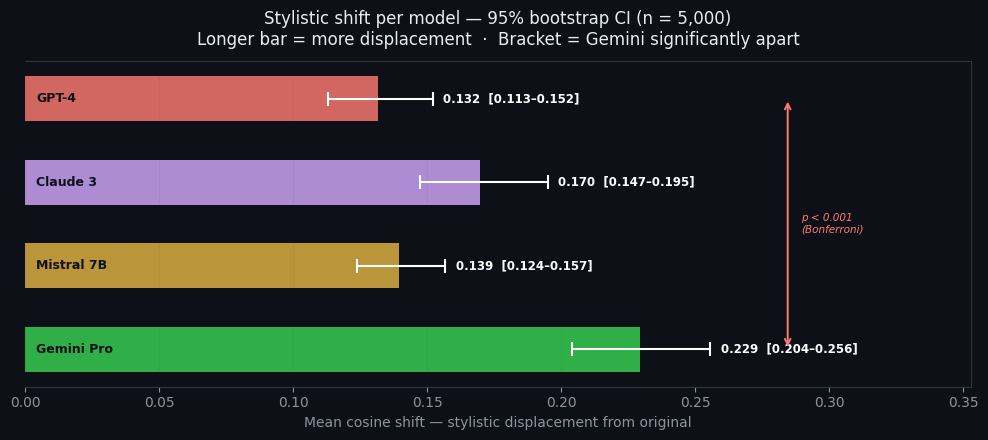

In [5]:
# Horizontal CI chart with significance bracket
model_names = list(shifts_all.keys())
means_ci    = [(np.mean(v), *bootstrap_ci(v)) for v in shifts_all.values()]

fig, ax = plt.subplots(figsize=(10, 4.5))
fig.patch.set_facecolor(THEME['bg'])
ax.set_facecolor(THEME['bg'])
ax.tick_params(colors=THEME['muted'])
for sp in ax.spines.values(): sp.set_edgecolor(THEME['spine'])

for i, (name, (mean, lo, hi)) in enumerate(zip(reversed(model_names), reversed(means_ci))):
    color = PALETTE[name]
    ax.barh(i, mean, color=color, alpha=0.82, height=0.54, edgecolor='none')
    ax.errorbar(mean, i, xerr=[[mean - lo], [hi - mean]],
                fmt='none', color='white', capsize=5, capthick=1.5, elinewidth=1.5, zorder=4)
    ax.text(hi + 0.004, i, f'{mean:.3f}  [{lo:.3f}–{hi:.3f}]',
            va='center', color='white', fontsize=8.5, fontweight='bold')
    ax.text(0.004, i, name, va='center', ha='left',
            color=THEME['bg'], fontsize=9, fontweight='bold', zorder=5)

g_idx  = list(reversed(model_names)).index('Gemini Pro')
p_idx  = list(reversed(model_names)).index('GPT-4')
g_mean = means_ci[model_names.index('Gemini Pro')][0]
bx     = g_mean + 0.055
ax.annotate('', xy=(bx, p_idx), xytext=(bx, g_idx),
            arrowprops=dict(arrowstyle='<->', color='#FF7B72', lw=1.4))
ax.text(bx + 0.005, (p_idx + g_idx) / 2, 'p < 0.001\n(Bonferroni)',
        color='#FF7B72', fontsize=7.5, va='center', fontstyle='italic')

ax.set_yticks([])
ax.spines['left'].set_visible(False)
ax.set_xlabel('Mean cosine shift — stylistic displacement from original', color=THEME['muted'])
ax.set_title('Stylistic shift per model — 95% bootstrap CI (n = 5,000)\n'
             'Longer bar = more displacement  ·  Bracket = Gemini significantly apart',
             color=THEME['text'], pad=12)
ax.set_xlim(0, max(hi for _, lo, hi in means_ci) * 1.38)
ax.grid(axis='x', alpha=0.05, color=THEME['grid'])
plt.tight_layout()
plt.show()

## 4 — Drift trajectories in PCA style-space

Every text is a point in 41-dimensional function-word space. PCA projects this to 2D preserving maximum variance.

- **★ Human centroid** = mean position of the 80 originals
- **Arrows** = direction and magnitude of each model's drift
- **Δ label** = mean cosine shift (same numbers as the CI chart)

> Gemini's arrow is ~75% longer than GPT-4's. GPT-4 and Mistral point in nearly identical directions.

In [6]:
all_vecs, all_lbls = [], []
orig_vecs = sa.fit_transform(originals)
for v in orig_vecs:
    all_vecs.append(v); all_lbls.append('Humain')
for lbl, rewrites in llm_corpora.items():
    for v in sa.fit_transform(rewrites):
        all_vecs.append(v); all_lbls.append(lbl)

X       = np.array(all_vecs)
lbl_arr = np.array(all_lbls)
pca     = PCA(n_components=2, random_state=42)
coords  = pca.fit_transform(X)
var     = pca.explained_variance_ratio_ * 100

human_mask     = lbl_arr == 'Humain'
human_centroid = coords[human_mask].mean(axis=0)
llm_labels     = list(llm_corpora.keys())
llm_centroids  = {l: coords[lbl_arr == l].mean(axis=0) for l in llm_labels}

print(f'PCA variance: PC1={var[0]:.1f}%  PC2={var[1]:.1f}%')
print()
print(f'  {"Model":<15}  Euclidean dist from human centroid')
for lbl, c in llm_centroids.items():
    print(f'  {lbl:<15}  {np.linalg.norm(c - human_centroid):.4f}')

PCA variance: PC1=13.7%  PC2=13.1%

  Model            Euclidean dist from human centroid
  GPT-4            0.0686
  Claude 3         0.0211
  Mistral 7B       0.1096
  Gemini Pro       0.1586


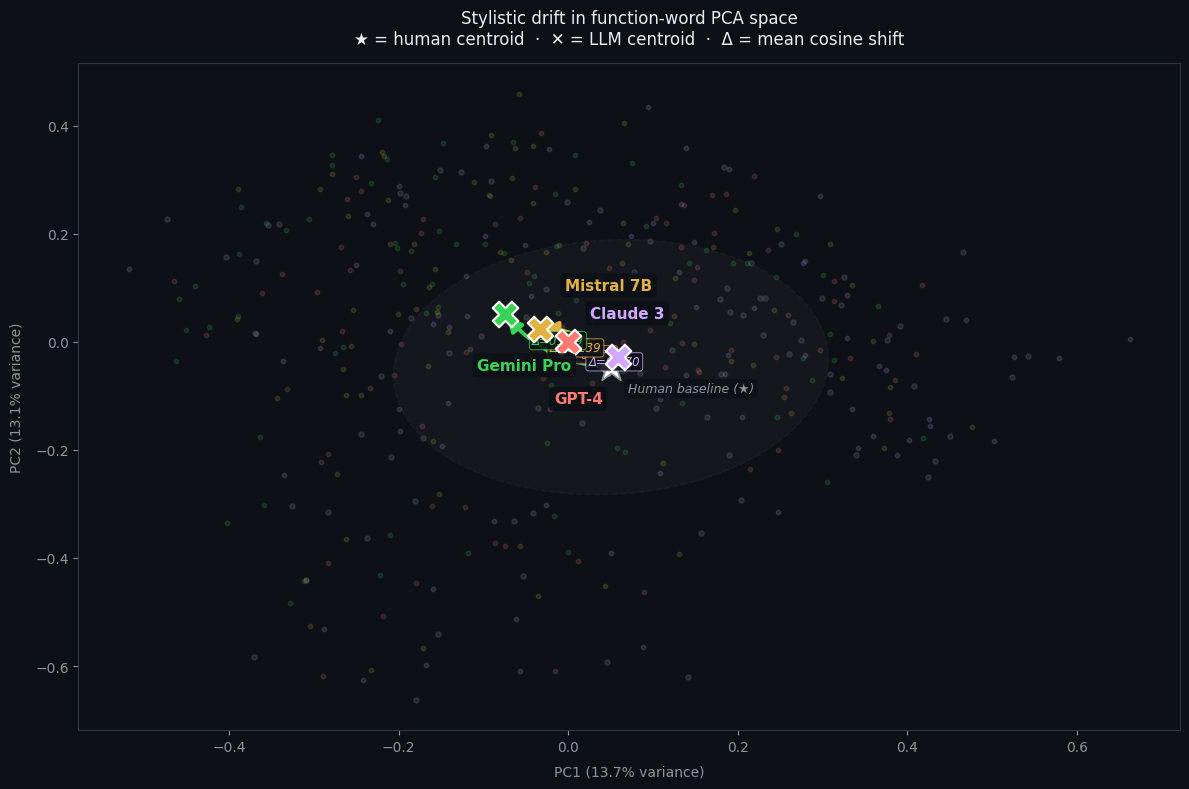

In [7]:
fig, ax = plt.subplots(figsize=(12, 8))
fig.patch.set_facecolor(THEME['bg'])
ax.set_facecolor(THEME['bg'])
ax.tick_params(colors=THEME['muted'])
for sp in ax.spines.values(): sp.set_edgecolor(THEME['spine'])

# Human scatter + 1-sigma ellipse
ax.scatter(*coords[human_mask].T, c=THEME['muted'], s=14, alpha=0.18, zorder=2, rasterized=True)
h_pts = coords[human_mask]
vals, vecs = np.linalg.eigh(np.cov(h_pts.T))
order = vals.argsort()[::-1]; vals, vecs = vals[order], vecs[:, order]
w_, h_ = 2 * np.sqrt(np.maximum(vals, 0))
ax.add_patch(Ellipse(xy=human_centroid, width=w_, height=h_,
                     angle=np.degrees(np.arctan2(*vecs[:, 0][::-1])),
                     fc=THEME['muted'], alpha=0.06, ec=THEME['muted'], lw=1.2, ls='--'))

# LLM scatter
for label in llm_labels:
    ax.scatter(*coords[lbl_arr == label].T, c=PALETTE[label], s=10, alpha=0.15, zorder=3, rasterized=True)

# Human centroid — star
ax.scatter(*human_centroid, c='white', s=520, marker='*',
           edgecolors=THEME['muted'], linewidths=1.2, zorder=8)
ax.annotate('Human baseline (★)', human_centroid, xytext=(12, -18), textcoords='offset points',
            color=THEME['muted'], fontsize=9, fontstyle='italic',
            bbox=dict(boxstyle='round,pad=0.25', fc=THEME['bg'], ec='none', alpha=0.80))

# Arrows
arrow_rads    = {'GPT-4': 0.18, 'Claude 3': -0.15, 'Mistral 7B': 0.28, 'Gemini Pro': -0.22}
label_offsets = {'GPT-4': (-10,-44), 'Claude 3': (-20,28), 'Mistral 7B': (18,28), 'Gemini Pro': (-20,-40)}

for label in llm_labels:
    color  = PALETTE[label]
    cx, cy = llm_centroids[label]
    ms     = float(np.mean(shifts_all[label]))
    ax.annotate('', xy=(cx, cy), xytext=human_centroid,
                arrowprops=dict(arrowstyle='-|>', color=color, lw=2.8,
                                connectionstyle=f'arc3,rad={arrow_rads[label]}',
                                mutation_scale=22), zorder=7)
    mid = 0.5 * (human_centroid + np.array([cx, cy]))
    ax.annotate(f'Δ={ms:.3f}', mid, color=color, fontsize=8.5, fontstyle='italic',
                ha='center', va='center',
                bbox=dict(boxstyle='round,pad=0.22', fc=THEME['bg'], ec=color, alpha=0.88, lw=0.6), zorder=9)
    ax.scatter([cx], [cy], c=color, s=340, marker='X', edgecolors='white', linewidths=1.5, zorder=10)
    dx, dy = label_offsets[label]
    ax.annotate(label, (cx, cy), color=color, fontsize=11, fontweight='bold',
                xytext=(dx, dy), textcoords='offset points',
                bbox=dict(boxstyle='round,pad=0.3', fc=THEME['bg'], ec='none', alpha=0.90), zorder=11)

ax.set_xlabel(f'PC1 ({var[0]:.1f}% variance)', color=THEME['muted'], labelpad=8)
ax.set_ylabel(f'PC2 ({var[1]:.1f}% variance)', color=THEME['muted'], labelpad=8)
ax.set_title('Stylistic drift in function-word PCA space\n'
             '★ = human centroid  ·  ✕ = LLM centroid  ·  Δ = mean cosine shift',
             color=THEME['text'], pad=14)
ax.grid(alpha=0.03, color=THEME['grid'])
plt.tight_layout()
plt.show()

## 5 — Which function words drive the drift?

Arrows show *how much*. This heatmap shows *which words* deviate from the human baseline — and in which direction.

- **Red** = overuse relative to human baseline  
- **Blue** = underuse  
- Top 12 words = most discriminative between models (SVM linear OVR)

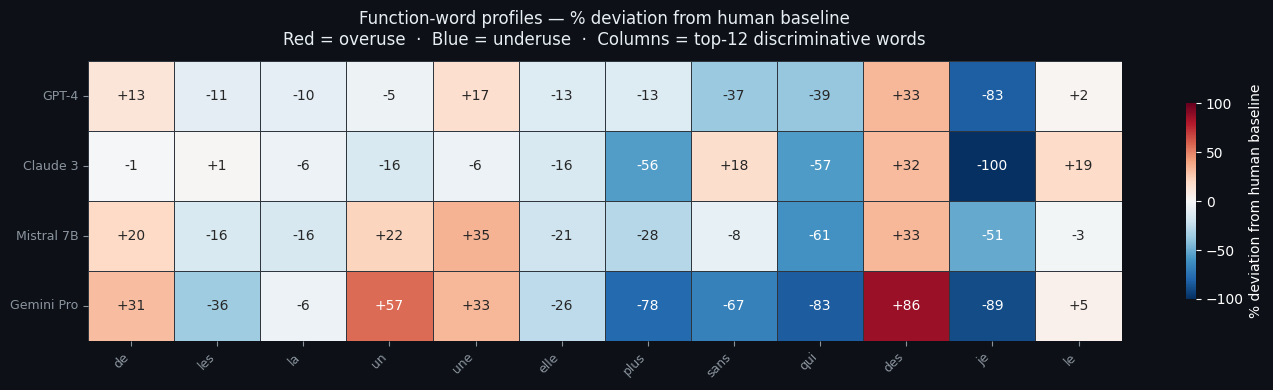

In [8]:
llm_names_list = list(llm_corpora.keys())
X_llm = np.vstack([sa.fit_transform(texts) for texts in llm_corpora.values()])
y_llm = np.concatenate([np.full(len(texts), i) for i, texts in enumerate(llm_corpora.values())])

svm     = SVC(kernel='linear', C=1.0, decision_function_shape='ovr')
svm.fit(StandardScaler().fit_transform(X_llm), y_llm)
top_idx   = np.argsort(np.abs(svm.coef_).mean(axis=0))[::-1][:12]
top_words = [sa.function_words[i] for i in top_idx]

zola       = load_human('zola')
maupassant = load_human('maupassant')

def word_freq(texts, words):
    tokens = re.findall(r'\b\w+\b', ' '.join(texts).lower())
    n = len(tokens)
    return np.array([tokens.count(w) / n * 100 for w in words])

baseline = word_freq(zola + maupassant, top_words)
matrix   = []
for lbl in llm_names_list:
    freq = word_freq(llm_corpora[lbl], top_words)
    matrix.append(np.where(baseline > 0, (freq - baseline) / baseline * 100, 0.0))
data = np.array(matrix)

vmax = max(60.0, float(np.abs(data).max()))
fig, ax = plt.subplots(figsize=(14, 4))
fig.patch.set_facecolor(THEME['bg'])
ax.set_facecolor(THEME['surface'])
sns.heatmap(data, annot=True, fmt='+.0f', cmap='RdBu_r', center=0,
            vmin=-vmax, vmax=vmax, xticklabels=top_words, yticklabels=llm_names_list,
            ax=ax, linewidths=0.4, linecolor=THEME['spine'],
            cbar_kws={'shrink': 0.7, 'label': '% deviation from human baseline'})
ax.set_title('Function-word profiles — % deviation from human baseline\n'
             'Red = overuse  ·  Blue = underuse  ·  Columns = top-12 discriminative words',
             color=THEME['text'], pad=12)
plt.setp(ax.get_xticklabels(), rotation=45, ha='right', color=THEME['muted'], fontsize=9)
plt.setp(ax.get_yticklabels(), rotation=0, color=THEME['muted'], fontsize=9)
ax.tick_params(colors=THEME['muted'])
plt.tight_layout()
plt.show()

## 6 — KDE ridgeline: shift distributions

Each ridge = one model's distribution of per-text shifts across 80 texts.  
White vertical line = mean. Width = density at each shift value.

GPT-4 and Mistral ridges overlap almost entirely — they occupy the same region of shift-space.

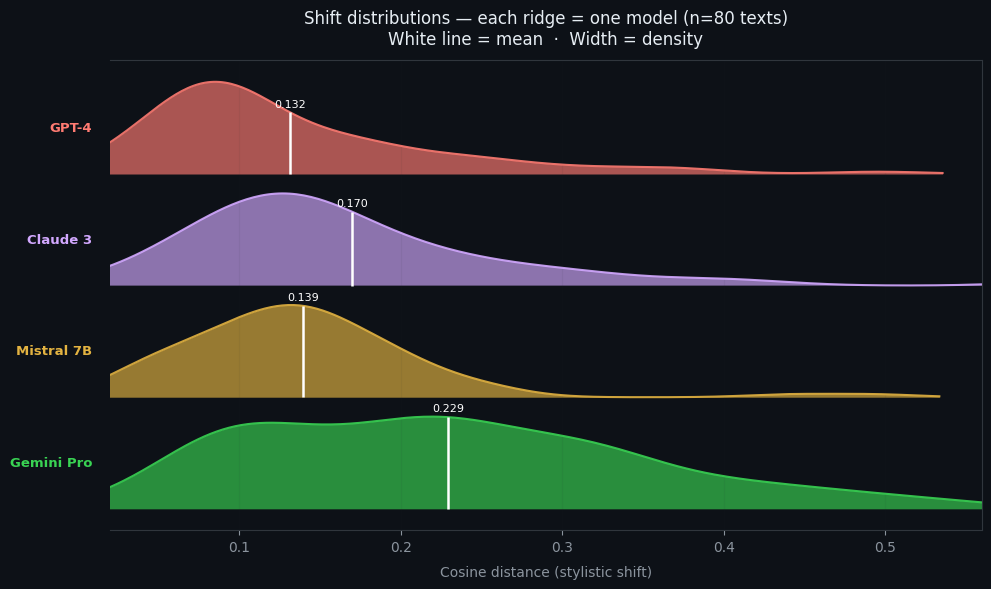

In [9]:
spacing = 1.15
fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor(THEME['bg'])
ax.set_facecolor(THEME['bg'])
ax.tick_params(colors=THEME['muted'])
for sp in ax.spines.values(): sp.set_edgecolor(THEME['spine'])
trans = blended_transform_factory(ax.transAxes, ax.transData)

for i, name in enumerate(reversed(list(shifts_all.keys()))):
    shifts = np.array(shifts_all[name])
    y_off  = i * spacing
    color  = PALETTE[name]
    x_kde  = np.linspace(max(0.0, shifts.min() - 0.04), shifts.max() + 0.04, 300)
    kde    = gaussian_kde(shifts, bw_method=0.35)
    y_raw  = kde(x_kde)
    y_norm = y_raw / y_raw.max() * 0.95
    ax.fill_between(x_kde, y_off, y_norm + y_off, color=color, alpha=0.65, lw=0)
    ax.plot(x_kde, y_norm + y_off, color=color, lw=1.5, alpha=0.90)
    mean_val    = float(shifts.mean())
    mean_height = kde(mean_val)[0] / y_raw.max() * 0.95
    ax.vlines(mean_val, y_off, mean_height + y_off, color='white', lw=1.8, zorder=4)
    ax.annotate(f'{mean_val:.3f}', (mean_val, mean_height + y_off + 0.04),
                color='white', fontsize=8, ha='center', va='bottom')
    ax.text(-0.02, y_off + 0.48, name, ha='right', va='center',
            color=color, fontsize=9.5, fontweight='bold', transform=trans)

ax.set_yticks([])
ax.set_xlim(0.02, 0.56)
ax.spines['left'].set_visible(False)
ax.set_xlabel('Cosine distance (stylistic shift)', color=THEME['muted'], labelpad=8)
ax.set_title('Shift distributions — each ridge = one model (n=80 texts)\n'
             'White line = mean  ·  Width = density',
             color=THEME['text'], pad=12)
ax.grid(axis='x', alpha=0.06, color=THEME['grid'])
plt.tight_layout()
plt.show()

## Summary

| Model | Mean shift | 95% CI | Statistical structure |
|-------|:----------:|:------:|:---------------------:|
| Gemini Pro | **0.230** | [0.204, 0.256] | Distinct — p < 0.001 vs all others |
| Claude 3 | **0.170** | [0.147, 0.195] | Grey zone — not sig. different from either cluster |
| Mistral 7B | **0.139** | [0.124, 0.157] | Statistically = GPT-4 (p = 1.0) |
| GPT-4 | **0.132** | [0.113, 0.152] | Statistically = Mistral (p = 1.0) |

**Four key takeaways:**
1. All models displace style measurably — no rewrite is stylistically neutral
2. There are effectively **2 clusters**, not 4: {GPT-4, Mistral} ≈ one group; Gemini = outlier
3. Each model has a characteristic *direction* of drift in style-space, not just a magnitude
4. **Function-word shifts are not the most discriminative signal** — surface statistics (sentence rhythm, TTR, punctuation) reach 57.5% LOO accuracy vs 40.6% for shift vectors alone (→ see notebook 02)

---
→ **Next**: [02_classification.ipynb](02_classification.ipynb) — 8 feature sets, best = 57.5% LOO — can a classifier tell the models apart?